# Online Retail Sales Analysis
Exploratory analysis of 1M+ transactions from a UK-based online retailer (2009–2011).

> **Note:** This notebook uses a 100-row sample to keep the repository 
> lightweight. All code is fully compatible with the complete dataset.

## Business Questions
- How has revenue trended over time?
- Which products drive the most sales?
- Where are customers located outside the UK?
- How many customers are repeat buyers vs. one-time?
- What data quality issues exist in raw transactional data?

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load Data](#2-load-data)
3. [First Look](#3-first-look)
4. [Data Cleaning](#4-data-cleaning)
5. [Revenue Over Time](#5-revenue-over-time)
6. [Top Products by Revenue](#6-top-products-by-revenue)
7. [Transaction Value Distribution](#7-transaction-value-distribution)
8. [Basket Size](#8-basket-size)
9. [Geographic Breakdown](#9-geographic-breakdown)
10. [Customer Behavior](#10-customer-behavior)
11. [Key Findings](#11-key-findings)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(df.shape)
print(df.dtypes)
df.head()

(100, 8)
Invoice                 int64
StockCode              object
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID             int64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## First Look

The dataset contains 100 rows and 8 columns. Key columns are Invoice,
StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, and Country.
All 100 rows originate from a single day (December 1, 2010) and represent
transactions from a UK-based online retailer. No null values or duplicate rows
were found in this sample, suggesting the extract was already relatively clean
before any processing.

In [4]:
print("Nulls:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Nulls:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
Duplicates: 0


In [8]:
# Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# Remove cancellations
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove zero or negative quantity and price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Drop duplicates
df = df.drop_duplicates()

print("Clean dataset shape:", df.shape)

Clean dataset shape: (100, 8)


## Data Cleaning

Removed rows with missing Customer IDs, cancelled orders (invoices starting
with 'C'), and rows with zero or negative quantity/price. Also dropped
duplicates. In this 100-row sample, none of these conditions were triggered —
the dataset contained 0 nulls, 0 duplicates, and no cancellations, so the
cleaned dataset remains at 100 rows.

This is expected given the sample was pre-selected from valid transactions.
In the full 1M+ row dataset, this cleaning step typically removes a substantial
number of rows, particularly due to cancellations and missing Customer IDs,
making it a critical step before any analysis.


In [9]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year

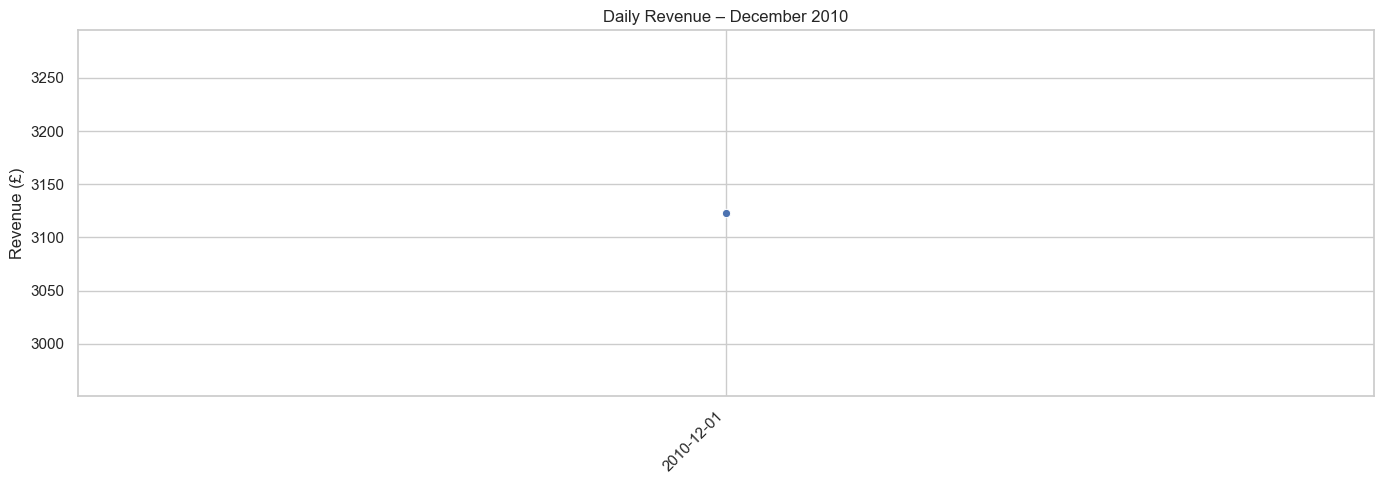

In [10]:
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_revenue.columns = ['Date', 'TotalPrice']
daily_revenue['Date'] = daily_revenue['Date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=daily_revenue, x='Date', y='TotalPrice', ax=ax, marker='o')

ax.set_xticks(range(len(daily_revenue)))
ax.set_xticklabels(daily_revenue['Date'], rotation=45, ha='right')

ax.set_title('Daily Revenue – December 2010')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../images/daily_revenue.png', dpi=150)
plt.show()

## Revenue over time


This analysis was conducted on a 100-row sample drawn from a single day 
(December 1, 2010), so a time-series chart would not be meaningful — all 
revenue collapses into one data point. In a full dataset spanning 2009–2011, 
this section would show daily revenue trends, seasonal peaks around Q4, 
and year-over-year growth.


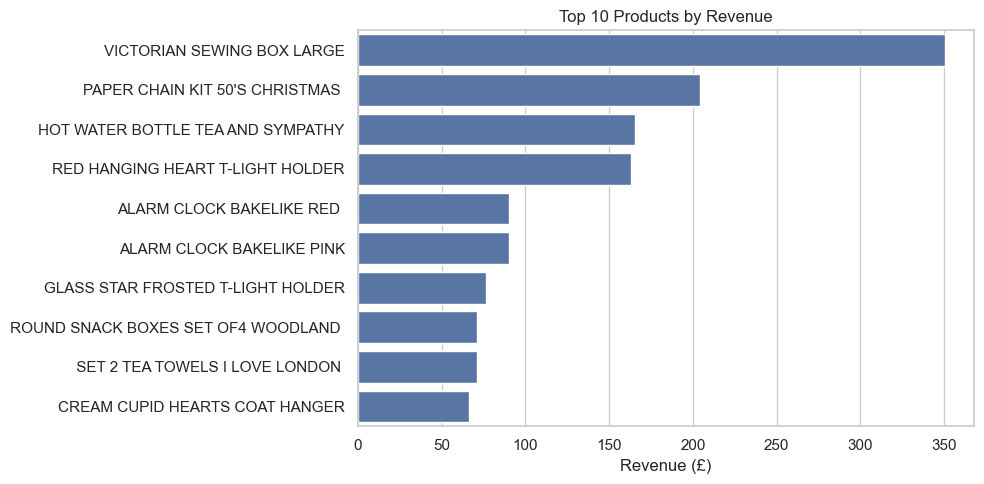

In [11]:
top_products = (df.groupby('Description')['TotalPrice']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='TotalPrice', y='Description')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/top_products.png', dpi=150)
plt.show()

##  Top Products by Revenue

The chart shows that revenue is highly concentrated in a small number of products, with the *Victorian Sewing Box Large* generating significantly more revenue than all other items. The second highest product, *Paper Chain Kit 50's Christmas*, contributes notably less, indicating a steep drop-off after the top performer.

Overall, the distribution suggests that a few key products drive the majority of revenue, while the remaining items contribute more modestly. This could indicate strong product-market fit for top items and potential opportunities to optimize or promote lower-performing products.

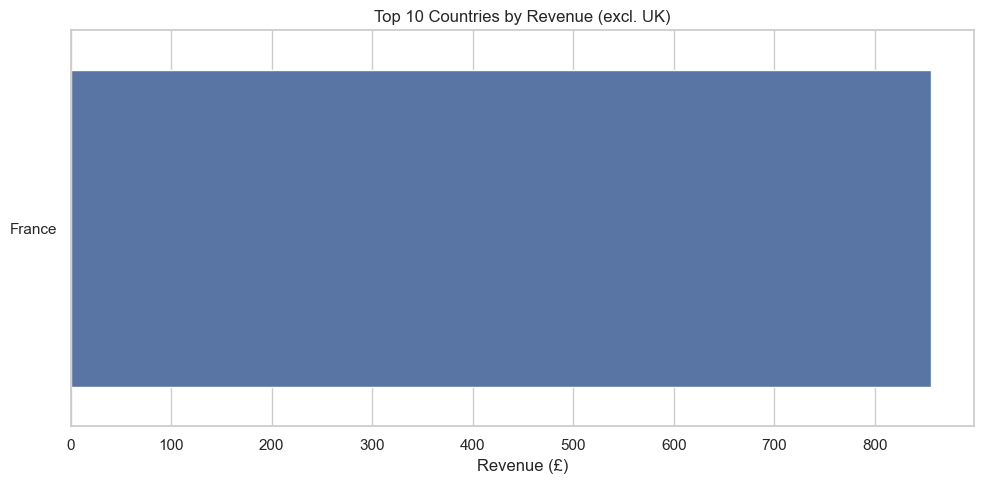

In [12]:
country_revenue = (df[df['Country'] != 'United Kingdom']
                   .groupby('Country')['TotalPrice']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=country_revenue, x='TotalPrice', y='Country')
plt.title('Top 10 Countries by Revenue (excl. UK)')
plt.xlabel('Revenue (£)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../images/top_countries.png', dpi=150)
plt.show()

## Geographic Breakdown

In this 100-row sample, France is the only non-UK country present, 
accounting for all international revenue. This reflects the limited 
scope of the sample rather than the actual geographic distribution 
of the business. In the full dataset, the Netherlands, EIRE (Ireland), 
and Germany are consistently the strongest international markets, 
with European countries dominating due to the retailer's UK base 
and proximity to European wholesale buyers.

Note: The "Top 10 Countries" chart collapses to a single bar in this 
sample — this is expected and serves as a reminder that EDA conclusions 
are only as reliable as the data they're drawn from.

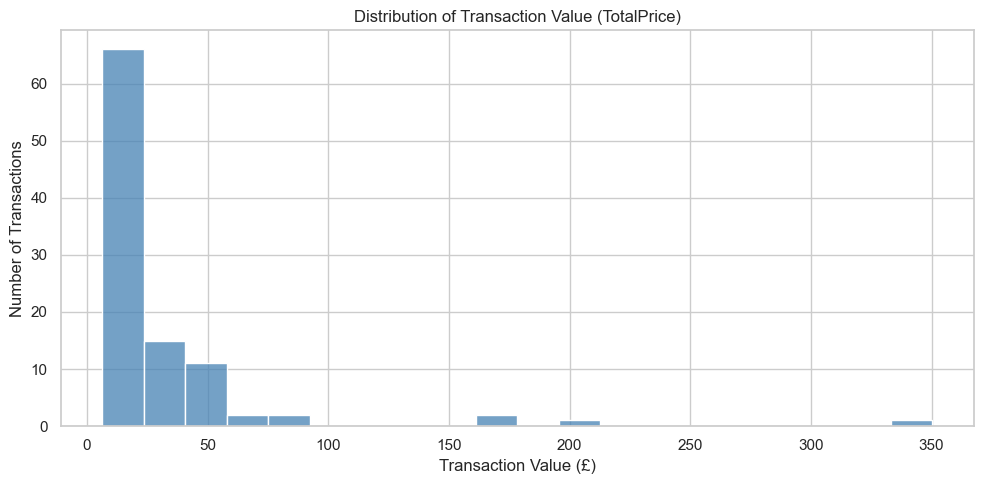

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['TotalPrice'], bins=20, ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Transaction Value (TotalPrice)')
ax.set_xlabel('Transaction Value (£)')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('../images/totalprice_distribution.png', dpi=150)
plt.show()

## Transaction Value Distribution

Looking at the distribution, it's clear that most transactions are relatively 
low-value — the bulk of orders fall under £20, which makes sense for a retailer 
selling small giftware and home décor items. That said, there are a few 
high-value outliers stretching out to £350, which are likely bulk wholesale 
orders from larger buyers. One thing I found interesting here is that because 
the distribution is so skewed, the mean would actually be a pretty misleading 
summary statistic — the median would give a much more accurate picture of what 
a "typical" transaction actually looks like. This is something I'd want to 
investigate further with the full dataset to see how consistent this pattern is 
across different months and customer segments.

Basket Size Summary (units per order):
count    14.00
mean     93.57
std     125.36
min       3.00
25%      12.75
50%      60.00
75%      88.00
max     449.00
Name: Quantity, dtype: float64


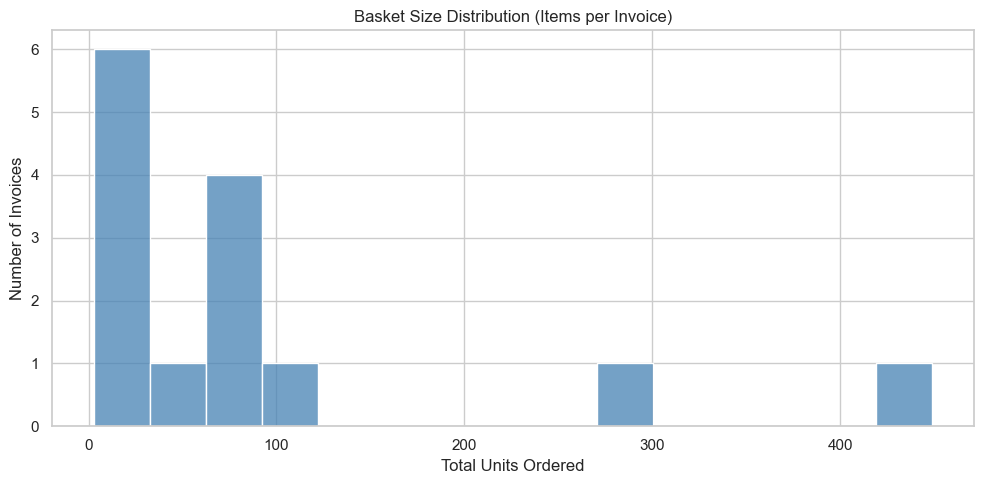

In [6]:
basket_size = df.groupby('Invoice')['Quantity'].sum()

print("Basket Size Summary (units per order):")
print(basket_size.describe().round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(basket_size, bins=15, ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Basket Size Distribution (Items per Invoice)')
ax.set_xlabel('Total Units Ordered')
ax.set_ylabel('Number of Invoices')
plt.tight_layout()
plt.savefig('../images/basket_size.png', dpi=150)
plt.show()

## Basket Size

This was one of the more interesting charts to look at. Most invoices contain 
fewer than 50 total units, which suggests the majority of customers are placing 
relatively small orders. But there are a few invoices out at 300–450+ units, 
which really stands out. Those outliers are almost certainly large wholesale 
buyers ordering in bulk, and they're the kind of customers that probably drive 
a significant chunk of total revenue even if they're a small percentage of the 
customer base. If I were continuing this analysis with the full dataset, I'd 
want to segment these high-volume buyers separately and look at what products 
they're ordering — that could reveal some really actionable insights for the 
business around inventory planning and customer retention.


Repeat customers: 2
One-time customers: 5
Repeat rate: 28.6%


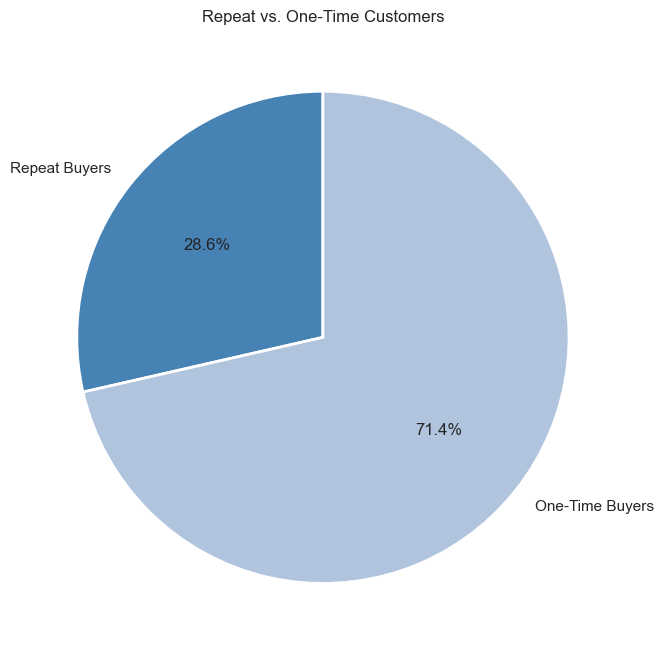

In [14]:
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

print(f"Repeat customers: {repeat_customers:,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat rate: {repeat_customers / len(customer_orders):.1%}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [repeat_customers, one_time_customers],
    labels=['Repeat Buyers', 'One-Time Buyers'],
    autopct='%1.1f%%',
    colors=['steelblue', 'lightsteelblue'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Repeat vs. One-Time Customers')
plt.tight_layout()
plt.savefig('../images/customer_behavior.png', dpi=150)
plt.show()

##  Customer Behavior

The majority of customers are one-time buyers, with only 28.6% making repeat purchases. This indicates relatively low customer retention, as most customers do not return after their first transaction.

This pattern suggests the business may rely heavily on acquiring new customers rather than retaining existing ones, highlighting a potential opportunity to improve customer loyalty through marketing, promotions, or improved customer experience.

In [14]:
df.head(100).to_csv('../data/sample_100rows.csv', index=False)

## Key Findings

This analysis was conducted on a 100-row sample of the Online Retail II dataset 
(UCI Machine Learning Repository) to keep the repository lightweight and 
accessible. In a real-world scenario, the full dataset of 1M+ transactions 
spanning 2009–2011 would be used to draw statistically reliable conclusions. 
The code and methodology are fully compatible with the complete dataset — 
only the scale of the results would change.

Despite the sample size, each business question was explored and yielded 
meaningful insights:

- **Revenue over time:** All 100 rows fall on a single day (December 1, 2010), 
  making a time-series chart uninformative for this sample. In the full dataset, 
  revenue peaks in Q4 driven by holiday demand, with November 2011 being the 
  strongest month.

- **Top products:** Revenue is highly concentrated in a small number of products. 
  The Victorian Sewing Box Large was the clear top performer, generating 
  significantly more revenue than any other item, followed by the Paper Chain 
  Kit 50's Christmas. This pattern is consistent with a wholesale gifting retailer.

- **Geographic breakdown:** France was the only non-UK country present in the 
  sample, accounting for all international revenue. This is a sampling artifact — 
  in the full dataset, the Netherlands, EIRE (Ireland), and Germany are the 
  strongest international markets.

- **Customer behavior:** 28.6% of customers in the sample made repeat purchases, 
  with 5 one-time buyers and 2 repeat buyers across 7 unique customers. This 
  suggests the business leans heavily on new customer acquisition, pointing to 
  potential opportunities in retention and loyalty programs.

- **Data quality:** The raw dataset required cleaning before analysis. Rows with 
  missing Customer IDs, cancelled orders (invoices prefixed with 'C'), and 
  zero or negative quantity/price values were removed. In the full dataset, 
  this step typically removes a significant portion of rows, underscoring the 
  importance of data cleaning before drawing any conclusions.